# 概率与条件概率

学习目标：能为小型随机试验建立概率模型，分清不同条件下的概率，并用全概率与贝叶斯公式核对计算和模拟结果。

前置知识：集合、有限求和、基本计数、Python 容器与函数、NumPy 数组索引。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；仅使用本地生成的小数据。

环境准备：[数学基础运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 先列清一次试验可能得到什么

同时观察两枚有编号的六面骰子。用有序对 $(i,j)$ 记录结果，i 是第一枚的点数，j 是第二枚的点数，二者都取 1 到 6。一次试验只得到其中一个有序对，$(4,6)$ 与 $(6,4)$ 是不同结果。

样本空间（sample space）$\Omega$ 是所有可能结果的集合；单个结果记为 $\omega\in\Omega$。本例有 $6\times6=36$ 个结果。事件（event）是样本空间的子集，例如 $A=\{(i,j):i+j\ge10\}$ 表示“点数和至少为 10”。实际结果落在 A 中，就说 A 发生。

先采用明确的模型假设：这 36 个有序结果各有概率 1/36。于是 A 包含 6 个结果，$P(A)=6/36=1/6$，其中 P 表示给事件赋概率的规则。这个等概率假设是模型的一部分，不能只凭列出了 36 个结果就认定它成立。

In [1]:
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np

omega = {(i, j) for i in range(1, 7) for j in range(1, 7)}
event_a = {(i, j) for i, j in omega if i + j >= 10}

print("样本空间大小：", len(omega))  # 36。
print("和至少为 10：", sorted(event_a))  # 6 个有序结果。
print("P(A) =", Fraction(len(event_a), len(omega)))  # 1/6，保留精确分数。

样本空间大小： 36
和至少为 10： [(4, 6), (5, 5), (5, 6), (6, 4), (6, 5), (6, 6)]
P(A) = 1/6


再定义事件 $B=\{(i,j):i\text{ 为偶数}\}$。交集 $A\cap B$ 表示两个条件同时满足；并集 $A\cup B$ 表示至少满足一个，包含同时满足的结果；补集 $A^c=\Omega\setminus A$ 表示 A 不发生。空集 $\varnothing$ 是不可能事件，整个 $\Omega$ 是必然事件。

下面先用集合运算明确每个事件的范围，再计算概率。不能把“至少一个发生”当成“恰好一个发生”。

In [2]:
event_b = {(i, j) for i, j in omega if i % 2 == 0}
print("A 与 B 同时满足：", sorted(event_a & event_b))  # 4 个结果。
print("A 或 B 至少一个满足：", len(event_a | event_b))  # 20 个结果。
print("A 不发生：", len(omega - event_a))  # 30 个结果。
print("恰好一个发生：", len(event_a ^ event_b))  # 16，不包含交集。

A 与 B 同时满足： [(4, 6), (6, 4), (6, 5), (6, 6)]
A 或 B 至少一个满足： 20
A 不发生： 30
恰好一个发生： 16


## 2 概率规则与等概率计数

概率遵守非负性 $P(E)\ge0$、归一化 $P(\Omega)=1$，以及互不相交事件的可加性。这里 E 表示任意事件；对两两不相交的有限或可数事件 $E_1,E_2,\ldots$，有

$$P\!\left(\bigcup_k E_k\right)=\sum_kP(E_k).$$

本章只计算有限样本空间。把 $\Omega$ 分成 $E$ 与 $E^c$，可得 $P(E^c)=1-P(E)$，并有 $P(\varnothing)=0$、$0\le P(E)\le1$。一般的两个事件可能重叠，其加法公式为

$$P(A\cup B)=P(A)+P(B)-P(A\cap B).$$

减去交集，是因为前两项把交集算了两次。若有限样本空间中每个结果等概率，则 $P(E)=|E|/|\Omega|$，竖线表示集合元素个数。下面的函数只服务于当前这个等概率骰子模型；Fraction 用整数分子、分母表示精确有理数。

In [3]:
def probability(event):
    """计算当前 36 个等概率有序结果中的事件概率。"""
    return Fraction(len(event), len(omega))


print("补集规则：", probability(omega - event_a), 1 - probability(event_a))  # 预期为 5/6 5/6。
# 预期为 5/9 5/9。
print(
    "加法公式：",
    probability(event_a | event_b),
    probability(event_a) + probability(event_b) - probability(event_a & event_b),
)
print("空集与全集：", probability(set()), probability(omega))  # 预期为 0 1。
# 两条计算路径分别得到 5/6、5/9；空集为 0，全集为 1。

补集规则： 5/6 5/6
加法公式： 5/9 5/9
空集与全集： 0 1


### 2.1 结果不等概率时，逐项相加

对有限样本空间，若单个结果 $\omega$ 的概率是 $p_\omega$，必须满足 $p_\omega\ge0$、$\sum_{\omega\in\Omega}p_\omega=1$，事件概率为 $P(E)=\sum_{\omega\in E}p_\omega$。

另造一枚偏骰：1 到 5 点各有概率 1/10，6 点有概率 1/2。这只是教学设定，不是对实际骰子的测量。虽然“偶数”占六种点数中的三种，其概率也不再是 3/6。这里不能调用前面默认 36 个结果等概率的函数。

In [4]:
face_probability = {face: Fraction(1, 10) for face in range(1, 6)}
face_probability[6] = Fraction(1, 2)
p_even = sum(p for face, p in face_probability.items() if face % 2 == 0)
print("总概率：", sum(face_probability.values()))  # 1。
print("偏骰出现偶数：", p_even)  # 7/10，不能用 3/6。

总概率： 1
偏骰出现偶数： 7/10


## 3 条件概率改变分母所代表的范围

回到 36 个等概率结果。现在已知 B，即第一枚点数为偶数。可保留的结果从 36 个变成 18 个，其中 A 仍满足的结果只有 4 个。因此“已知 B，A 发生”的条件概率（conditional probability）是 $P(A\mid B)=4/18=2/9$。

一般定义为

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)},\qquad P(B)>0.$$

分母是条件事件 B 的概率，分子是 A 与 B 同时发生的概率。只有在等概率的有限模型中，才可进一步写成 $|A\cap B|/|B|$。交换 A 和 B 就是在问另一件事：本例 $P(B\mid A)=4/6=2/3$。

In [5]:
p_a_given_b = probability(event_a & event_b) / probability(event_b)
p_b_given_a = probability(event_a & event_b) / probability(event_a)
print("P(A) =", probability(event_a))  # 1/6。
print("P(A|B) =", p_a_given_b)  # 2/9。
print("P(B|A) =", p_b_given_a)  # 2/3；交换条件后数值不同。
# 预期为 1。
print(
    "条件内的归一化：",
    p_a_given_b + probability((omega - event_a) & event_b) / probability(event_b),
)
# 固定条件 B 后，A 与 A 的补集的条件概率相加为 1。

P(A) = 1/6
P(A|B) = 2/9
P(B|A) = 2/3
条件内的归一化： 1


把两个分母画在同一个 6×6 网格上。横轴是第一枚点数，纵轴是第二枚点数；橙色点满足 A，蓝色点属于当前可用范围但不满足 A，灰色点已被条件排除。右图应只在剩余 18 个彩色点内数比例。

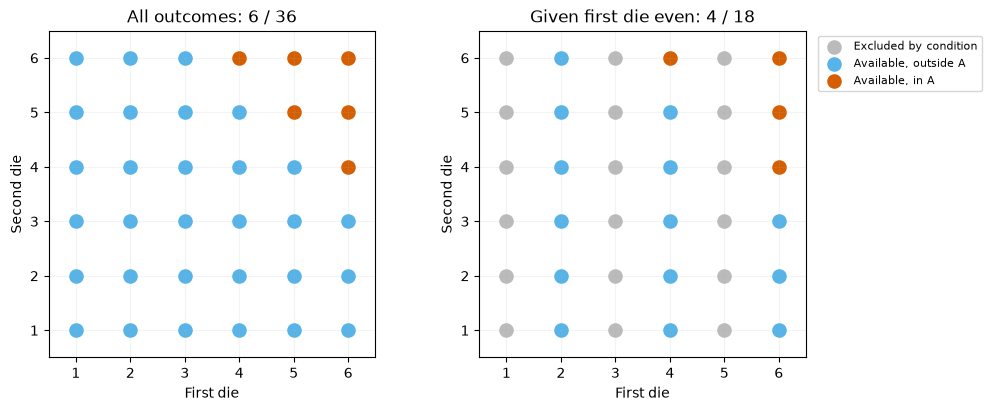

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
# 左右图分别以全集和 B 为可用范围；同一颜色始终代表同一类结果。
for ax, condition, title in zip(
    axes, [omega, event_b], ["All outcomes: 6 / 36", "Given first die even: 4 / 18"]
):
    categories = [
        (omega - condition, "#BBBBBB", "Excluded by condition"),
        (condition - event_a, "#56B4E9", "Available, outside A"),
        (condition & event_a, "#D55E00", "Available, in A"),
    ]
    for event, color, label in categories:
        # 将有序二元结果转成两列坐标；reshape 也保持空类别的形状为 (0, 2)。
        points = np.array(sorted(event)).reshape(-1, 2)
        ax.scatter(points[:, 0], points[:, 1], s=90, color=color, label=label)
    ax.set(
        title=title,
        xlabel="First die",
        ylabel="Second die",
        xticks=range(1, 7),
        yticks=range(1, 7),
        xlim=(0.5, 6.5),
        ylim=(0.5, 6.5),
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.15)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
# 预期左图橙点占 6/36；右图排除奇数第一骰后，橙点占可用点的 4/18。
plt.show()

### 3.1 条件必须有正概率

把条件换成“第一枚为奇数”或“第一枚为 6”，会得到不同的分母和交集。如果条件事件概率为零，本章的比值定义就不能使用，不能把 0/0 当成 0。

下面把条件事件逐一写出。条件描述本身也是模型输入的一部分；“已知至少一枚为 6”与“已知第一枚为 6”并不是同一个条件。

In [7]:
conditions = {
    "第一枚为偶数": event_b,
    "第一枚为奇数": omega - event_b,
    "第一枚为 6": {(i, j) for i, j in omega if i == 6},
    "至少一枚为 6": {(i, j) for i, j in omega if i == 6 or j == 6},
    "第一枚为 7": {(i, j) for i, j in omega if i == 7},
}
for name, condition in conditions.items():
    if probability(condition) == 0:
        print(name, "：条件概率未定义，不能除以零")  # “第一枚为 7”是空事件，打印条件概率未定义。
    else:
        value = probability(event_a & condition) / probability(condition)
        # 其余四种条件下的概率依次为 2/9、1/9、1/2、5/11。
        print(
            f"{name}：交集 {len(event_a & condition)} / 条件 {len(condition)} = {value}"
        )
# 依次得到 2/9、1/9、1/2、5/11；最后一种条件不代入比值。

第一枚为偶数：交集 4 / 条件 18 = 2/9
第一枚为奇数：交集 2 / 条件 18 = 1/9
第一枚为 6：交集 3 / 条件 6 = 1/2
至少一枚为 6：交集 5 / 条件 11 = 5/11
第一枚为 7 ：条件概率未定义，不能除以零


## 4 乘法公式不要求独立

把条件概率定义两边乘以分母，得到

$$P(A\cap B)=P(B)P(A\mid B),\qquad P(B)>0.$$

若 $P(A)>0$，也可写成 $P(A)P(B\mid A)$。乘法公式中的条件概率不能随意换成无条件概率。本例先筛选 B，再在其中筛选 A，得到 $(1/2)(2/9)=1/9$；反过来筛选得到 $(1/6)(2/3)=1/9$。

In [8]:
direct = probability(event_a & event_b)
by_b = probability(event_b) * p_a_given_b
by_a = probability(event_a) * p_b_given_a
print("直接计数、先 B 后 A、先 A 后 B：", direct, by_b, by_a)  # 预期为 1/9 1/9 1/9。
print("错误地直接相乘：", probability(event_a) * probability(event_b))  # 预期为 1/12。
# 前三项都是 1/9；无条件概率乘积为 1/12，本例不能这样替换。

直接计数、先 B 后 A、先 A 后 B： 1/9 1/9 1/9
错误地直接相乘： 1/12


## 5 独立不等于互斥

两个事件独立（independent）的定义是 $P(E\cap F)=P(E)P(F)$，其中 E、F 是任意两个事件。当 $P(F)>0$ 时，这等价于 $P(E\mid F)=P(E)$。定义中的乘积形式也适用于零概率事件，避免了除以零。

互斥（mutually exclusive）则要求 $E\cap F=\varnothing$，即一次结果不能同时满足两个事件。如果 E、F 都有正概率且互斥，那么交集概率是 0，而 $P(E)P(F)>0$，所以它们一定不独立。若其中一个概率为零，不能套用这条“正概率”结论。

令 C 表示第二枚点数至少为 5，D 表示两枚点数和至多为 3。在当前模型中，B 与 C 可以同时发生且独立；A 与 D 互斥且不独立；A 与 B 则既不互斥也不独立。

In [9]:
event_c = {(i, j) for i, j in omega if j >= 5}
event_d = {(i, j) for i, j in omega if i + j <= 3}
for name, left, right in [
    ("B 与 C", event_b, event_c),
    ("A 与 D", event_a, event_d),
    ("A 与 B", event_a, event_b),
]:
    joint = probability(left & right)
    product = probability(left) * probability(right)
    # B、C 独立且不互斥；A、D 互斥但不独立；A、B 两者都不是。
    print(
        f"{name}：交集概率={joint}，边缘乘积={product}，互斥={not (left & right)}，独立={joint == product}"
    )
# 用精确分数比较：B/C 是 1/6=1/6；A/D 是 0≠1/72；A/B 是 1/9≠1/12。

B 与 C：交集概率=1/6，边缘乘积=1/6，互斥=False，独立=True
A 与 D：交集概率=0，边缘乘积=1/72，互斥=True，独立=False
A 与 B：交集概率=1/9，边缘乘积=1/12，互斥=False，独立=False


### 5.1 是否放回会改变抽样模型

袋中有“蓝1、蓝2、橙1”三个可区分的球，每次从当时袋中的球均匀抽取。若不放回，两次有序抽取共有 6 个等概率结果。已知第一次为蓝色后，第二次为蓝色的概率是 1/2；不知道第一次颜色时，第二次为蓝色的概率是 2/3，所以这两个蓝色事件不独立。

若每次放回并重新均匀抽取，且第二次选择不依赖第一次结果，则有 9 个等概率有序结果。此时第一次的颜色不会改变第二次蓝色概率。这里独立来自完整的抽样假设，不能只看到“分两次做”就认定独立。

In [10]:
balls = ["蓝1", "蓝2", "橙1"]
without_replacement = [(a, b) for a in balls for b in balls if a != b]
with_replacement = [(a, b) for a in balls for b in balls]
for name, outcomes in [
    ("不放回", without_replacement),
    ("放回且独立均匀抽取", with_replacement),
]:
    first_blue = [pair for pair in outcomes if pair[0].startswith("蓝")]
    second_blue = [pair for pair in outcomes if pair[1].startswith("蓝")]
    both_blue = [pair for pair in first_blue if pair[1].startswith("蓝")]
    # 不放回时条件概率 1/2 不等于边缘概率 2/3；放回时两者均为 2/3。
    print(
        name,
        "：P(第二次蓝)=",
        Fraction(len(second_blue), len(outcomes)),
        "；P(第二次蓝|第一次蓝)=",
        Fraction(len(both_blue), len(first_blue)),
        "；P(两次蓝)=",
        Fraction(len(both_blue), len(outcomes)),
    )
# 两种模型的第二次蓝概率都是 2/3；条件概率依次为 1/2、2/3。
# 两次蓝的概率依次为 1/3、4/9，不能混用样本空间。

不放回 ：P(第二次蓝)= 2/3 ；P(第二次蓝|第一次蓝)= 1/2 ；P(两次蓝)= 1/3
放回且独立均匀抽取 ：P(第二次蓝)= 2/3 ；P(第二次蓝|第一次蓝)= 2/3 ；P(两次蓝)= 4/9


## 6 全概率公式把不同来源汇总起来

设 $H_1,\ldots,H_m$ 是样本空间的一个划分：m 为正整数，这些事件两两互斥、并集为 $\Omega$，且这里要求每个 $P(H_k)>0$。对任意事件 E，$E\cap H_k$ 也两两互斥，并且合起来恰好是 E。因此

$$P(E)=\sum_{k=1}^{m}P(E\cap H_k)
=\sum_{k=1}^{m}P(E\mid H_k)P(H_k).$$

这就是全概率公式（law of total probability）。它按各来源的概率加权，通常不能把各条件概率直接取算术平均。若划分中有零概率部分，它对交集概率的贡献为零，应省去该部分，不能计算一个未定义的条件概率再乘零。

对骰子模型，令 $H_k$ 表示第一枚点数为 k，k 从 1 到 6。逐行数出“和至少为 10”的条件概率，再汇总回 $P(A)$。此例各来源恰好同为 1/6。

In [11]:
total = Fraction(0)
for face in range(1, 7):
    part = {(i, j) for i, j in omega if i == face}
    p_part = probability(part)
    p_a_given_part = probability(event_a & part) / p_part
    contribution = p_a_given_part * p_part
    total += contribution
    # 六个来源概率均为 1/6；对 A 的贡献依次为 0、0、0、1/36、1/18、1/12。
    print(
        f"第一枚={face}：来源概率={p_part}，条件概率={p_a_given_part}，贡献={contribution}"
    )
print("全概率汇总：", total, "；直接计数：", probability(event_a))  # 预期为 1/6 ；直接计数： 1/6。
# 前三行贡献为 0，后三行贡献为 1/36、1/18、1/12，总和 1/6。

第一枚=1：来源概率=1/6，条件概率=0，贡献=0
第一枚=2：来源概率=1/6，条件概率=0，贡献=0
第一枚=3：来源概率=1/6，条件概率=0，贡献=0
第一枚=4：来源概率=1/6，条件概率=1/6，贡献=1/36
第一枚=5：来源概率=1/6，条件概率=1/3，贡献=1/18
第一枚=6：来源概率=1/6，条件概率=1/2，贡献=1/12
全概率汇总： 1/6 ；直接计数： 1/6


## 7 贝叶斯公式用证据更新来源概率

设 H 是某个待判断的事件，E 是已知的证据，且 $P(H)>0$、$P(E)>0$。把同一个交集的乘法公式写两遍：

$$P(H\mid E)P(E)=P(H\cap E)=P(E\mid H)P(H).$$

所以贝叶斯公式（Bayes' theorem）为

$$P(H\mid E)=\frac{P(E\mid H)P(H)}{P(E)}.$$

$P(H)$ 是看到证据前的先验概率（prior probability），$P(E\mid H)$ 描述 H 成立时证据出现的概率，$P(H\mid E)$ 是看到证据后的后验概率（posterior probability）。同一个交集并没有变，改变的是归一化所用的条件。

若 $H_1,\ldots,H_m$ 满足上一节的划分与正概率条件，再用全概率公式展开 $P(E)$，得到

$$P(H_k\mid E)=\frac{P(E\mid H_k)P(H_k)}{\sum_{j=1}^{m}P(E\mid H_j)P(H_j)},\qquad P(E)>0.$$

这些后验概率对 k 求和为 1。在骰子例子中取 H=B、E=A，就能从 $P(A\mid B)$ 反向算出 $P(B\mid A)$。

In [12]:
posterior_b = p_a_given_b * probability(event_b) / probability(event_a)
posterior_not_b = (
    probability(event_a & (omega - event_b))
    / probability(omega - event_b)
    * probability(omega - event_b)
    / probability(event_a)
)
print("先验 P(B)：", probability(event_b))  # 1/2。
print("后验 P(B|A)：", posterior_b)  # 2/3，与直接条件计数一致。
print("后验归一化：", posterior_b + posterior_not_b)  # 1。

先验 P(B)： 1/2
后验 P(B|A)： 2/3
后验归一化： 1


## 8 综合应用：告警后发生故障的概率

为一个教学告警器设定以下模型。H 表示设备处于故障状态，E 表示发出告警；没有故障与没有告警分别记为 $H^c$、$E^c$。设

$$P(H)=0.02,\qquad P(E\mid H)=0.90,\qquad P(E\mid H^c)=0.05.$$

2% 是故障基率（base rate），90% 是故障设备中的告警比例，5% 是正常设备中的误报比例。三者均为人工指定的概率，不来自真实设备数据。目标是告警后故障的概率 $P(H\mid E)$，不能直接把它写成 90%。

两条产生告警的路径分别贡献 $0.90\times0.02=0.018$ 与 $0.05\times0.98=0.049$，所以

$$P(E)=0.018+0.049=0.067,\qquad
P(H\mid E)=\frac{0.018}{0.067}=\frac{18}{67}\approx0.2687.$$

正常设备占比大，即使误报比例较小，它们仍可贡献较多告警。此处只是对给定模型做条件计算；告警与故障的条件关系也不是“发出告警导致故障”的因果结论。

In [13]:
prior_fault = Fraction(2, 100)
alarm_given_fault = Fraction(90, 100)
alarm_given_normal = Fraction(5, 100)

fault_and_alarm = alarm_given_fault * prior_fault
normal_and_alarm = alarm_given_normal * (1 - prior_fault)
p_alarm = fault_and_alarm + normal_and_alarm
fault_given_alarm = fault_and_alarm / p_alarm
print("两个告警来源：", fault_and_alarm, normal_and_alarm)  # 预期为 9/500 49/1000。
print("P(告警)：", p_alarm)  # 67/1000。
print(
    "P(故障|告警)：", fault_given_alarm, float(fault_given_alarm)
)  # 18/67，约 0.2687。
print("误用两组简单平均：", (alarm_given_fault + alarm_given_normal) / 2)  # 预期为 19/40。
# 0.475 与正确的 0.067 不同，因为两种设备状态的概率不是各占一半。

两个告警来源： 9/500 49/1000
P(告警)： 67/1000
P(故障|告警)： 18/67 0.26865671641791045
误用两组简单平均： 19/40


### 8.1 同一张表，不同条件用不同分母

把模型等价地写成 1000 个等概率编号的有限总体：其中 18 个编号为“故障且告警”，2 个为“故障且未告警”，49 个为“正常且告警”，931 个为“正常且未告警”。从这 1000 个编号中均匀选一个，得到的四格概率与上述模型完全相同。这是人为构造的总体，不是一次模拟的实测频数。

| 状态 | 告警 E | 未告警 $E^c$ | 行总数 |
| --- | ---: | ---: | ---: |
| 故障 H | 18 | 2 | 20 |
| 正常 $H^c$ | 49 | 931 | 980 |
| 列总数 | 67 | 933 | 1000 |

四格分别除以 1000 得到交集概率；按行除以行总数，得到已知设备状态时的告警概率；按列除以列总数，得到已知告警状态时的故障概率。每次除法都要知道自己固定了哪个条件。

In [14]:
counts = np.array([[18, 2], [49, 931]])
joint_table = counts / counts.sum()
alarm_given_state = counts / counts.sum(axis=1, keepdims=True)
state_given_alarm = counts / counts.sum(axis=0, keepdims=True)

print("交集概率表：\n", joint_table)  # 预期约为 [[0.018 0.002] [0.049 0.931]]。
print("已知设备状态，按行归一化：\n", np.round(alarm_given_state, 6))  # 预期约为 [[0.9 0.1 ] [0.05 0.95]]。
print("已知告警状态，按列归一化：\n", np.round(state_given_alarm, 6))  # 预期约为 [[0.268657 0.002144] [0.731343 0.997856]]。
# 预期约为 1 [1. 1.] [1. 1.]。
print(
    "归一化检查：",
    joint_table.sum(),
    alarm_given_state.sum(axis=1),
    state_given_alarm.sum(axis=0),
)
# 预期为 True。
print(
    "表中故障后验与公式一致：",
    Fraction(int(counts[0, 0]), int(counts[:, 0].sum())) == fault_given_alarm,
)
# 交集表整体和为 1；行条件表每行和为 1；列条件表每列和为 1。

交集概率表：
 [[0.018 0.002]
 [0.049 0.931]]
已知设备状态，按行归一化：
 [[0.9  0.1 ]
 [0.05 0.95]]
已知告警状态，按列归一化：
 [[0.268657 0.002144]
 [0.731343 0.997856]]
归一化检查： 1.0 [1. 1.] [1. 1.]
表中故障后验与公式一致： True


再核对“未告警”这一条件。分母应变为未告警总数 933，故 $P(H\mid E^c)=2/933$。它与 $1-P(H\mid E)=49/67$ 不相等；后者实际上是 $P(H^c\mid E)$，仍以“已告警”为条件。

对条件概率取补集时，应只改变所求事件，保持条件事件不变：$P(H^c\mid E)=1-P(H\mid E)$。

In [15]:
fault_given_no_alarm = (1 - alarm_given_fault) * prior_fault / (1 - p_alarm)
normal_given_alarm = 1 - fault_given_alarm
print("P(故障|未告警)：", fault_given_no_alarm, float(fault_given_no_alarm))  # 预期约为 2/933 0.00214362。
print("P(正常|告警)：", normal_given_alarm, float(normal_given_alarm))  # 预期约为 49/67 0.731343。
print("按表计数核对：", fault_given_no_alarm == Fraction(2, 933))  # 预期为 True。
# 两个不同条件的问题：约 0.002144 与 0.731343，不能互换。

P(故障|未告警)： 2/933 0.0021436227224008574
P(正常|告警)： 49/67 0.7313432835820896
按表计数核对： True


### 8.2 改变基率，后验也会改变

固定两种状态下的告警概率，仅把故障基率改为 $q\in(0,1)$，则

$$P(H\mid E)=\frac{0.90q}{0.90q+0.05(1-q)}.$$

q 表示当前总体中故障状态的概率。这是在“告警器的两个条件概率保持不变”这一假设下比较不同总体；实际迁移到另一个总体时，还需要核实该假设是否合适。

下图横轴是基率，纵轴是告警后的故障概率，均以百分比显示。虚线表示先验与后验数值相等的位置，实线来自本例的贝叶斯公式，不是拟合曲线。

基率 1% → 告警后的故障概率 15.3846%
基率 2% → 告警后的故障概率 26.8657%
基率 10% → 告警后的故障概率 66.6667%


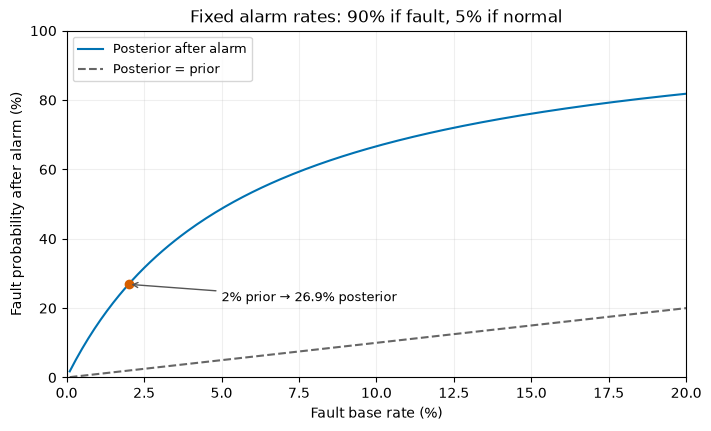

In [16]:
# 固定告警的条件概率，只改变故障基率并重新套用贝叶斯公式。
base_rates = np.linspace(0.001, 0.20, 200)
posteriors = 0.90 * base_rates / (0.90 * base_rates + 0.05 * (1 - base_rates))
for q in [0.01, 0.02, 0.10]:
    posterior = 0.90 * q / (0.90 * q + 0.05 * (1 - q))
    print(f"基率 {q:.0%} → 告警后的故障概率 {posterior:.4%}")  # 基率 1%、2%、10% 的后验依次约为 15.3846%、26.8657%、66.6667%。
# 同样的 90% / 5%，得到约 15.38%、26.87%、66.67%。

# 绘图时乘 100 换成百分数；虚线帮助比较告警前后的概率。
fig, ax = plt.subplots(figsize=(7, 4.2), layout="constrained")
ax.plot(
    100 * base_rates, 100 * posteriors, color="#0072B2", label="Posterior after alarm"
)
ax.plot(
    100 * base_rates, 100 * base_rates, "--", color="#666666", label="Posterior = prior"
)
ax.scatter([2], [100 * float(fault_given_alarm)], color="#D55E00", zorder=3)
ax.annotate(
    "2% prior → 26.9% posterior",
    xy=(2, 100 * float(fault_given_alarm)),
    xytext=(5, 22),
    arrowprops={"arrowstyle": "->", "color": "#555555"},
    fontsize=9,
)
ax.set(
    xlabel="Fault base rate (%)",
    ylabel="Fault probability after alarm (%)",
    title="Fixed alarm rates: 90% if fault, 5% if normal",
    xlim=(0, 20),
    ylim=(0, 100),
)
ax.grid(alpha=0.2)
ax.legend(loc="upper left", fontsize=9)
# 预期后验曲线随基率上升且位于对角虚线上方；标记点约为 (2%, 26.9%)。
plt.show()

## 9 用模拟频率观察，保留精确答案作对照

继续使用骰子的 36 个等概率有序结果。每次生成两枚点数，支持集都是 $\{1,2,3,4,5,6\}$，模型假设同一次的两枚骰子及不同次试验相互独立。使用局部 Generator，种子固定为 1515；做 1 组包含 20000 次试验的教学模拟。固定种子便于在同样的软件与调用条件下重现，不代表伪随机序列在所有版本间都相同。

若前 n 次试验中 A 出现 $N_A(n)$ 次，B 出现 $N_B(n)$ 次，二者同时出现 $N_{AB}(n)$ 次，则频率估计为

$$\widehat p_A(n)=\frac{N_A(n)}n,\qquad
\widehat p_{A\mid B}(n)=\frac{N_{AB}(n)}{N_B(n)},\quad N_B(n)>0.$$

帽号表示从样本计算的估计。条件频率的分母是满足 B 的次数，不是总试验数。模型中 $P(B)>0$ 也不保证一个很短的有限样本一定包含 B；没有条件样本时暂不计算该比值。

In [17]:
rng = np.random.default_rng(1515)
sample_size = 20_000
rolls = rng.integers(1, 7, size=(sample_size, 2))  # 上界 7 不包含在内。
hit_a = rolls.sum(axis=1) >= 10
hit_b = rolls[:, 0] % 2 == 0
hit_ab = hit_a & hit_b

# 固定模拟 20000 次；本次 A、B、交集次数依次为 3350、9937、2231。
print(
    "试验数、A 次数、B 次数、交集次数：",
    sample_size,
    int(hit_a.sum()),
    int(hit_b.sum()),
    int(hit_ab.sum()),
)
print("A 频率、理论值：", hit_a.mean(), float(probability(event_a)))  # 本次固定种子频率为 0.1675；理论概率为 1/6，约 0.166667。
# 本次固定种子的样本中 B 已出现，条件频率以 B 的实际次数为分母。
print("条件频率、理论值：", hit_ab.sum() / hit_b.sum(), float(p_a_given_b))  # 本次固定种子条件频率约 0.224514；理论值为 2/9，约 0.222222。
print("交集次数 / 全部试验数：", hit_ab.mean())  # 本次固定种子下交集频率为 0.11155，理论交集概率为 1/9。
# 最后一项估计 P(A∩B)=1/9，不能把它当作 P(A|B)=2/9。

试验数、A 次数、B 次数、交集次数： 20000 3350 9937 2231
A 频率、理论值： 0.1675 0.16666666666666666
条件频率、理论值： 0.22451444097816242 0.2222222222222222
交集次数 / 全部试验数： 0.11155


下面画出同一组试验中，随着累计样本数增加，频率如何变化。虚线是精确计数所得概率，实线是本次样本的频率。横轴采用对数尺度，以便同时看清早期和后期。

在独立、同分布的重复试验假设下，大数定律支持频率随样本数增加而在概率意义上接近理论概率；本章只引用这一结论。它不要求每增加一个样本误差都变小，也不保证某个有限样本恰好等于理论值。曲线靠近虚线不能代替概率规则的证明，也不能证明现实中的骰子满足模型假设。

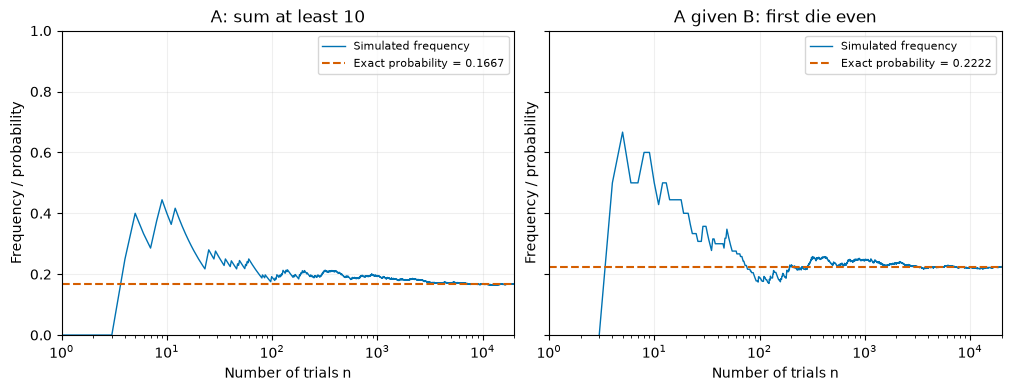

In [18]:
# 无条件频率以全部试验数为分母；条件频率只累计已出现的 B。
sample_counts = np.arange(1, sample_size + 1)
cumulative_a = np.cumsum(hit_a) / sample_counts
cumulative_b = np.cumsum(hit_b)
cumulative_ab = np.cumsum(hit_ab)
# 最初尚未出现 B 时没有条件频率，保留 NaN，不把它画成概率零。
conditional_frequency = np.full(sample_size, np.nan)
np.divide(
    cumulative_ab, cumulative_b, out=conditional_frequency, where=cumulative_b > 0
)

# 共享纵轴，分别对照各自的精确概率；横轴用对数突出早期变化。
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True, layout="constrained")
for ax, frequency, theoretical, title in [
    (axes[0], cumulative_a, float(probability(event_a)), "A: sum at least 10"),
    (axes[1], conditional_frequency, float(p_a_given_b), "A given B: first die even"),
]:
    ax.plot(
        sample_counts,
        frequency,
        color="#0072B2",
        linewidth=1,
        label="Simulated frequency",
    )
    ax.axhline(
        theoretical,
        color="#D55E00",
        linestyle="--",
        label=f"Exact probability = {theoretical:.4f}",
    )
    ax.set(
        xscale="log",
        xlabel="Number of trials n",
        ylabel="Frequency / probability",
        title=title,
        ylim=(0, 1),
        xlim=(1, sample_size),
    )
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc="upper right")
# 本次两条频率轨迹后段分别在 1/6、2/9 附近波动；不会每一步都更接近理论线。
plt.show()

### 9.1 同样的样本量也会有不同结果

另用种子 1516 连续生成 5 组试验，每组 2000 次，仍采用同样的独立均匀模型。每组都输出条件样本量和估计误差，比较有限样本的波动。误差这里定义为“本组估计值减理论值”，不是置信区间。

不要挑出最接近理论值的一组，再把它当作模拟的固定精度。本例已有可枚举的精确答案，模拟主要用来理解频率，不需要用模拟替代计数。

In [19]:
repeat_rng = np.random.default_rng(1516)
repetitions = 5
trials_per_group = 2000
for group in range(1, repetitions + 1):
    group_rolls = repeat_rng.integers(1, 7, size=(trials_per_group, 2))
    group_a = group_rolls.sum(axis=1) >= 10
    group_b = group_rolls[:, 0] % 2 == 0
    condition_count = int(group_b.sum())
    # 本次五组均有条件样本；用每组自己的 B 次数作为分母。
    estimate = (group_a & group_b).sum() / condition_count
    error = estimate - float(p_a_given_b)
    # 本次五组条件频率约为 0.22846、0.24174、0.21472、0.21421、0.22769，在理论 2/9 两侧波动。
    print(
        f"第 {group} 组：B 次数={condition_count}，条件频率={estimate:.5f}，误差={error:+.5f}"
    )
# 各组结果通常不同；理论条件概率固定为 2/9。

第 1 组：B 次数=998，条件频率=0.22846，误差=+0.00623
第 2 组：B 次数=968，条件频率=0.24174，误差=+0.01951
第 3 组：B 次数=978，条件频率=0.21472，误差=-0.00750
第 4 组：B 次数=999，条件频率=0.21421，误差=-0.00801
第 5 组：B 次数=975，条件频率=0.22769，误差=+0.00547


## 本章小结

（1）先明确样本空间、事件和概率分配。只有有限且等概率时，才能用“满足条件的个数 / 总个数”。

（2）条件概率要写清条件事件，并检查其概率为正。交换条件或对条件取补集，会改变问题及分母。

（3）互斥描述事件不能同时发生，独立描述交集概率是否等于概率乘积。两个正概率的互斥事件不独立。

（4）全概率公式把互斥且完备的来源按其概率加权；贝叶斯公式用同一交集把条件方向反过来，基率参与计算。

（5）理论概率由模型决定，模拟频率由有限样本产生。条件频率使用条件样本量，模拟的接近程度不构成证明。

自查：看到“告警”后应在哪一列取分母？为什么故障中的告警率不等于告警中的故障率？为什么两个事件可以同时发生且仍然独立？

## 练习

（1）在正文骰子模型中，令 F 为“两枚点数相同”。精确计算 $P(F)$、$P(F\mid B)$ 与 $P(F\mid A)$，分别判断 F 与 B、F 与 A 是否独立。用交集概率等于乘积这一条件核对，不能只根据日常语言中的“相关”作判断。

In [20]:
event_f = {(i, j) for i, j in omega if i == j}
# 补充三个概率和两个独立性判断；同时打印相关交集和分母大小。

（2）仍用两蓝一橙的三个可区分球，计算“至少一次蓝色”的概率，分别使用不放回和放回且独立均匀抽取两种模型。用直接枚举与补集法核对。再求“第二次蓝色，已知第一次橙色”的概率，解释改变抽样假设后哪些数发生变化。

In [21]:
exercise_models = {
    "不放回": without_replacement,
    "放回且独立均匀抽取": with_replacement,
}
# 两种模型分别计算；补集为“两次都不是蓝色”。

（3）保持故障时告警率 90%、正常时误报率 5%，把故障基率从 2% 改为 0.5% 和 10%。分别算告警总概率、告警后的故障概率、未告警后的故障概率，并核对每个固定告警条件下的两种设备状态概率之和为 1。解释为什么不能沿用原来 1000 个编号的四格计数表。

In [22]:
exercise_base_rates = [Fraction(5, 1000), Fraction(1, 10)]
# 重新按“来源概率 × 条件概率”建立四格概率，再分别按列归一化。

（4）对骰子事件 A，分别在“至少一枚为 6”和“第一枚为 6”条件下精确计数，再用局部 Generator、固定种子、每组 5000 次和 4 组重复模拟核对。报告每组条件样本量、条件频率及误差。说明为什么同一个总试验数不代表相同的条件样本量，以及没有条件样本时应如何处理。

In [23]:
exercise_rng = np.random.default_rng(1517)
exercise_repetitions = 4
exercise_sample_size = 5000
# 先写出两个条件集合的精确答案，再模拟；分母使用对应条件的出现次数。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先写出补集：两次都抽到橙色。

提示 2：不放回时只有一个橙球；放回后第二次抽取的颜色概率恢复为原来的比例。

### 练习（2）参考解析

不放回时，两次都橙不可能，故至少一次蓝的概率为 1。已知第一次橙色，剩下两个球均为蓝色，第二次蓝的条件概率也为 1。

放回且独立均匀抽取时，两次都橙的概率为 $(1/3)^2=1/9$，故至少一次蓝为 $8/9$；给定第一次橙色，第二次蓝仍为 $2/3$。按可区分球枚举时，不放回有 6 个等可能有序结果，放回有 9 个；不能把两种样本空间共用同一分母。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | John Tsitsiklis，6.041 Fall 2010：[Lecture 1: Probability Models and Axioms](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/fee036e2e13527166fb7f8bcd0647844_MIT6_041F10_L01.pdf)，PDF 第 2–3 页，概率公理、有限等概率模型和可数可加性；[Lecture 2: Conditioning and Bayes' Rule](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/1d1520a08a59780bd49a9f0f12bf9af8_MIT6_041F10_L02.pdf)，PDF 第 1–2 页，正概率条件、乘法、全概率与贝叶斯公式。Jeremy Orloff、Jonathan Bloom：[18.05 Spring 2022 概率讲义](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_probability.pdf)，Class 3 §6、讲义页 7–8（PDF 第 23–24 页），独立性的乘积定义及零概率边界；Class 6 §3.1、讲义页 3（PDF 第 79 页），独立同分布条件下的大数定律。 |
| OpenStax：Introductory Statistics 2e | [§3.1 Terminology](https://openstax.org/books/introductory-statistics-2e/pages/3-1-terminology)，样本空间、事件、等概率计数、集合运算和条件事件；[§3.2 Independent and Mutually Exclusive Events](https://openstax.org/books/introductory-statistics-2e/pages/3-2-independent-and-mutually-exclusive-events)，独立、互斥以及放回与不放回模型；[§3.3 Two Basic Rules of Probability](https://openstax.org/books/introductory-statistics-2e/pages/3-3-two-basic-rules-of-probability)，The Multiplication Rule 与 The Addition Rule。 |
| Deep Learning 作者网站 | [Chapter 3: Probability and Information Theory](https://www.deeplearningbook.org/contents/prob.html)，§3.5、式 (3.5) 与其后段落，条件概率的正概率前提及与因果干预的区别；§3.11、式 (3.42)，贝叶斯规则和用全概率计算分母。 |
| Python 官方文档 | Python 3.12：[fractions](https://docs.python.org/3.12/library/fractions.html)，Fraction 的整数分子、分母构造及有理数运算。 |
| NumPy 官方文档 | NumPy 2.5：[Random Generator](https://numpy.org/doc/stable/reference/random/generator.html)，局部 Generator 与 default_rng；[Generator.integers](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.integers.html)，离散均匀整数、半开区间与输出形状；[Compatibility policy](https://numpy.org/doc/stable/reference/random/compatibility.html)，固定种子仍需保留生成器、版本与调用条件；[divide](https://numpy.org/doc/stable/reference/generated/numpy.divide.html)，out 与 where 控制零分母位置。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html)，离散结果及颜色标记；[Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)，概率公式曲线与模拟频率轨迹。 |